In [ ]:
# Import or install Sionna
try:
    import sionna.rt
except ImportError as e:
    import os
    os.system("pip install sionna-rt")
    import sionna.rt

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import mitsuba as mi
import numpy as np

no_preview = True # Toggle to False to use the preview widget

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

# Query the Mitsuba variant that was automatically selected by Sionna RT.
# There should be no need to adjust it, but if you do, make sure to select
# a variant ending in `*_ad_mono_polarized`.
print(f"Mitsuba variant: {mi.variant()}")

Mitsuba variant: llvm_ad_mono_polarized


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from sionna.rt import load_scene

scene = load_scene("/content/drive/MyDrive/sionna rt/test11_gml/citygml_export_4.1_3_38_bui.xml")

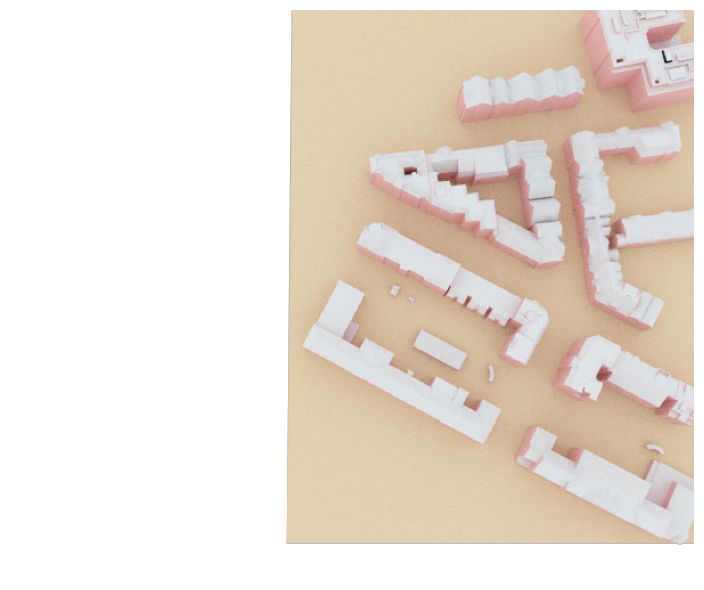

In [ ]:
my_cam = Camera(
    position=[60, 170, 380],
    look_at=[110, 170, 5]
)

scene.render(
    camera=my_cam,
    resolution=[600, 500],
    num_samples=128
);

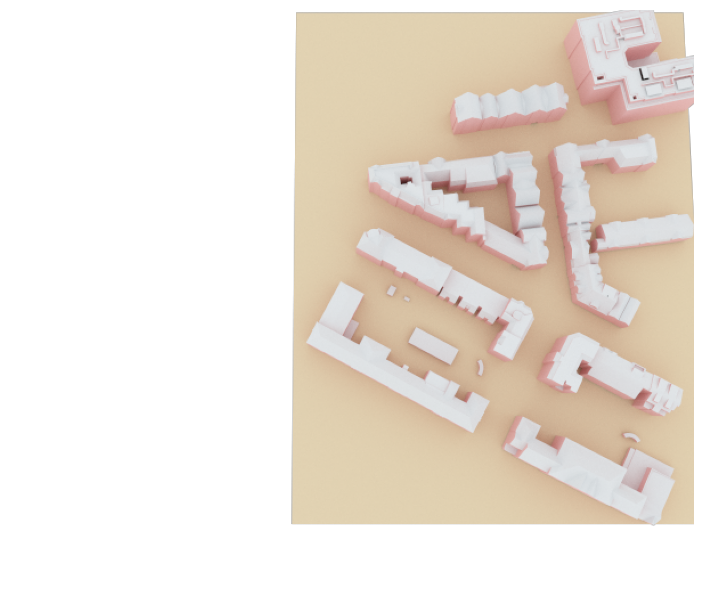

In [ ]:
my_cam = Camera(
    position=[60, 170, 410],
    look_at=[110, 170, 5]
)

scene.render(
    camera=my_cam,
    resolution=[600, 500],
    num_samples=1080
);

In [ ]:
# Configure antenna array for all transmitters
scene.tx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="tr38901",
    polarization="V"
)

# Configure antenna array for all receivers
scene.rx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="tr38901",
    polarization="V"
)

# Create transmitter
tx = Transmitter(
    name="tx1",
    position=[30, 70, 35],
)
scene.add(tx)

# Create five receivers
rx1 = Receiver(
    name="rx1",
    position=[116, 87, 7],
)
scene.add(rx1)

rx2 = Receiver(
    name="rx2",
    position=[98, 145, 7],
)
scene.add(rx2)

rx3 = Receiver(
    name="rx3",
    position=[123, 32, 7],
)
scene.add(rx3)

rx4 = Receiver(
    name="rx4",
    position=[189, 76, 7],
)
scene.add(rx4)

rx5 = Receiver(
    name="rx5",
    position=[145, 141, 7],
)
scene.add(rx5)

# Point transmitter towards one receiver (optional)
tx.look_at(rx1)

In [ ]:
# Instantiate a path solver
# The same path solver can be used with multiple scenes
p_solver  = PathSolver()

# Compute propagation paths
paths = p_solver(scene=scene,
                 max_depth=5,
                 los=True,
                 specular_reflection=True,
                 diffuse_reflection=False,
                 refraction=True,
                 synthetic_array=False,
                 seed=41)

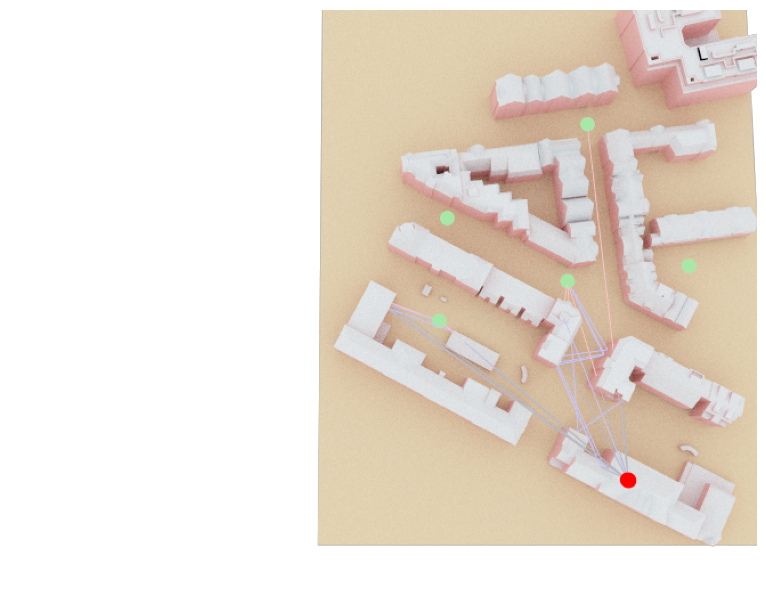

In [ ]:
if no_preview:
    scene.render(camera=my_cam, paths=paths, clip_at=40);
else:
    scene.preview(paths=paths, clip_at=40);

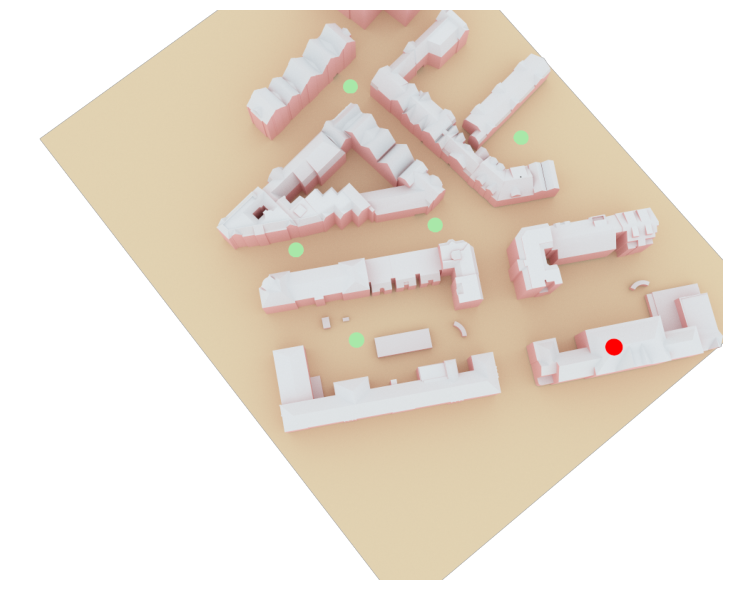

In [ ]:
my_cam = Camera(
    position=[60, 170, 370],
    look_at=[110, 130, 11]
)

scene.render(
    camera=my_cam,
    resolution=[1000, 800],
    num_samples=1080
);

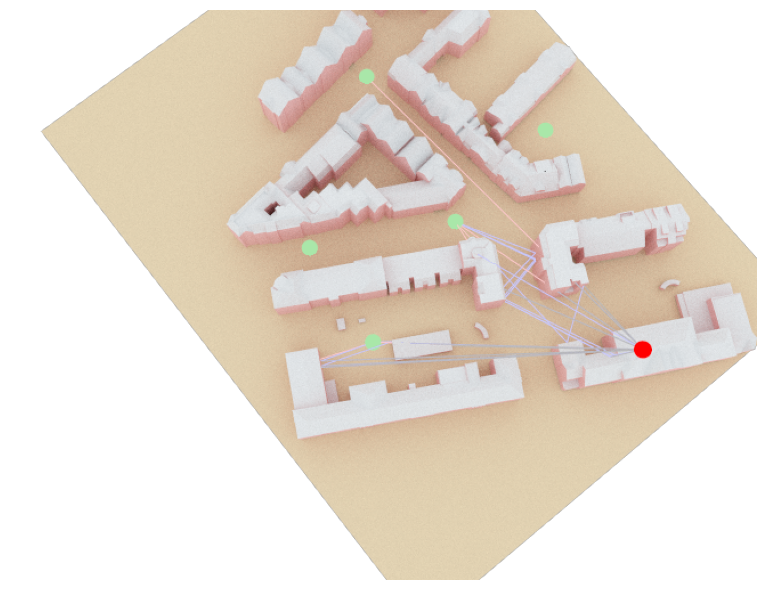

In [ ]:
if no_preview:
    scene.render(camera=my_cam, paths=paths, clip_at=40);
else:
    scene.preview(paths=paths, clip_at=40);

In [ ]:
a, tau = paths.cir(normalize_delays=True, out_type="numpy")

print("\nNumber of multipaths for each receiver:")
print("-" * 40)

for rx in range(a.shape[0]):

    # Get channel coefficients for this receiver
    a_rx = a[rx, 0, 0, 0, :, 0]   # first time step

    # Count paths with non-zero magnitude
    num_paths = (np.abs(a_rx) > 0).sum()

    print(f"Receiver {rx+1}: {num_paths} multipaths")


Number of multipaths for each receiver:
----------------------------------------
Receiver 1: 10 multipaths
Receiver 2: 12 multipaths
Receiver 3: 0 multipaths
Receiver 4: 2 multipaths
Receiver 5: 0 multipaths
